# TPC raw ADC → IBF and primary-density maps

This notebook starts from the native per-sector/per-module histograms produced by
`PHGarfieldRawHitsQA`:

`h_adc_pad_vs_layer_side{side}_sec{sector:02d}_R{module}_{QA_NAME}`

It is intentionally split into two independent parts.

## Part I — IBF
1. Load native `pad × layer` maps.
2. Detect vertical dead FEE regions wider than a configurable number of pads.
3. Detect full- and half-sector dead horizontal stripes.
4. Repair only **inside each sector**; sector gaps are never bridged.
5. Optionally suppress SAMPA/pad outliers using raw, sum, mean, median, or trimmed mean.
6. Convert cleaned ADC to an areal-density proxy using `r*dphi*dr`.
7. Smoothly extrapolate R1 inward to the 21 cm inner field cage.
8. Build side-0 and side-1 `rho(r,phi)` maps and diagnostic 2D fits.

## Part II — primary density
Starts again from the cleaned ADC map, optionally divides by a gain map, and makes
the same `r`, `phi`, and 2D-fit diagnostics.

For now `N_EVENTS = 1`. The absolute IBF scale is deliberately left free for later
PHGarfield/data tuning with distortion observables such as rDCA.


In [ ]:
import ROOT as root
import numpy as np
import math
from array import array
import matplotlib.pyplot as plt

#root.gROOT.SetBatch(True)
root.TH1.AddDirectory(False)

# ============================================================
# USER CONFIGURATION
# ============================================================

INPUT_ROOT = "input/tpc_poly_track_HITS_ppFieldOn_795130_qa.root"
QA_NAME = "PHGarfieldRawHitsQA"
N_EVENTS = 1.0

N_SIDES = 2
N_SECTORS = 12
N_MODULES = 3
LAYERS_PER_MODULE = 16
N_PADS = [94, 128, 192]

MIN_RADII_MODULE_MM = [314.9835971194212, 416.5920253621078, 589.1096334932404]
DELTA_RADII_MODULE_MM = [5.657908935192669, 10.206891263554285, 10.970474549405283]
AVR_DPHI_MODULE = [0.005307305707805798, 0.003959159565794228, 0.0026514278029726376]
AVR_MINPHI_MODULE = [1.3219316149976348, 1.3179398673058638, 1.3175593270455]

IFC_RADIUS_CM = 21.0

# ---- dead FEE detection ----
MIN_DEAD_FEE_WIDTH = 10          # require width > this value
DEAD_FEE_REL_THRESHOLD = 0.12
DEAD_FEE_ABS_EPS = 1e-12
FEE_CONTEXT_PADS = 8

# ---- dead stripe detection ----
DEAD_STRIPE_MODE = "neighbor"    # "neighbor" or "zero"
DEAD_STRIPE_REL_THRESHOLD = 0.12
HALF_STRIPE_FRACTION = 0.40
FULL_STRIPE_FRACTION = 0.85
STRIPE_NEIGHBOR_LAYERS = 2

# ---- pad/SAMPA estimator ----
# "raw", "sum", "mean", "median", "trimmed_mean"
ADC_ESTIMATOR = "trimmed_mean"
TRIM_FRACTION = 0.15
CLIP_OUTLIERS = False
CLIP_NSIGMA = 5.0

GLOBAL_PHI_BINS = 720
PHI_MIN = -math.pi
PHI_MAX = math.pi

# Inner extrapolation
IBF_R_EXTRAPOLATION = "linear"   # "constant", "linear", "poly2"
N_R1_FIT_LAYERS = 6
N_INNER_EXTRAP_BINS = 20

# Smooth diagnostic fit
FOURIER_ORDER = 12
RADIAL_POLY_ORDER = 3
FIT_MIN_DENSITY = 0.0

# Primary map. Leave None to use gain=1 for now.
GAIN_MAP_FILE = '../distort/input/layer_gain_79513_Mariia_side01.root'
GAIN_MAP_HIST = None             # may contain "{side}"
PRIMARY_DIVIDE_BY_GAIN = True

OUTPUT_ROOT = "TPC_IBF_primary_maps.root"

print("Configuration loaded")


Welcome to JupyROOT 6.30/06
Configuration loaded


## Geometry and ROOT helpers

Dead-region finding is performed in native sector coordinates. The conversion to
global `(r,phi)` happens only after repair.

The notebook currently reconstructs pad-center phi from the supplied average
module geometry. If exact `IdealPadMap` phi centers are later exported, replace
only `sector_phi_centers()`.


In [2]:
def get_hist_name(side, sector, module):
    return f"h_adc_pad_vs_layer_side{side}_sec{sector:02d}_R{module+1}_{QA_NAME}"

def th2_to_numpy(h):
    nx, ny = h.GetNbinsX(), h.GetNbinsY()
    z = np.empty((ny, nx), dtype=float)
    for iy in range(ny):
        for ix in range(nx):
            z[iy, ix] = h.GetBinContent(ix+1, iy+1)
    x = np.array([h.GetXaxis().GetBinCenter(i+1) for i in range(nx)])
    y = np.array([h.GetYaxis().GetBinCenter(i+1) for i in range(ny)])
    return z, x, y

def module_layer_radii_cm(module):
    r0 = MIN_RADII_MODULE_MM[module] / 10.0
    dr = DELTA_RADII_MODULE_MM[module] / 10.0
    return r0 + dr*(np.arange(LAYERS_PER_MODULE) + 0.5)

def module_dr_cm(module):
    return DELTA_RADII_MODULE_MM[module] / 10.0

def wrap_phi(phi):
    return (phi + np.pi) % (2*np.pi) - np.pi

def sector_phi_centers(module, sector, side=0):
    npads = N_PADS[module]
    dphi = AVR_DPHI_MODULE[module]
    sector_pitch = 2*np.pi/12.0
    phi0 = AVR_MINPHI_MODULE[module] + sector*sector_pitch
    return wrap_phi(phi0 + (np.arange(npads)+0.5)*dphi)

def pad_area_cm2(module, radii_cm):
    return radii_cm * AVR_DPHI_MODULE[module] * module_dr_cm(module)

def robust_scale(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return 0.0
    med = np.median(x)
    mad = np.median(np.abs(x-med))
    if mad > 0:
        return 1.4826*mad
    return np.std(x)

def clipped_values(x):
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return x
    med = np.median(x)
    sig = robust_scale(x)
    if sig <= 0 or not np.isfinite(sig):
        return x
    return x[np.abs(x-med) <= CLIP_NSIGMA*sig]

def estimate_values(x, mode=None):
    if mode is None:
        mode = ADC_ESTIMATOR
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return np.nan

    if mode == "sum":
        return np.sum(x)
    if mode == "raw":
        return np.mean(x)

    if CLIP_OUTLIERS:
        xc = clipped_values(x)
        if xc.size:
            x = xc

    if mode == "mean":
        return np.mean(x)
    if mode == "median":
        return np.median(x)
    if mode == "trimmed_mean":
        xs = np.sort(x)
        ntrim = int(TRIM_FRACTION*len(xs))
        if 2*ntrim >= len(xs):
            return np.median(xs)
        return np.mean(xs[ntrim:len(xs)-ntrim])

    raise ValueError(mode)


# Part I — IBF source shape

## 1. Load native sector/module maps

In [3]:
fin = root.TFile.Open(INPUT_ROOT, "READ")
if not fin or fin.IsZombie():
    raise OSError(f"Cannot open {INPUT_ROOT}")

raw_maps = {}
missing = []

for side in range(N_SIDES):
    for module in range(N_MODULES):
        for sector in range(N_SECTORS):
            name = get_hist_name(side, sector, module)
            h = fin.Get(name)
            if not h:
                missing.append(name)
                continue
            z, pads, layers = th2_to_numpy(h)
            raw_maps[(side,module,sector)] = {
                "adc": z/N_EVENTS,
                "pads": pads,
                "layers": layers,
                "name": name,
            }

print(f"Loaded {len(raw_maps)} maps")
if missing:
    print(f"Missing {len(missing)} histograms")
    print("\n".join(missing[:10]))


Loaded 72 maps


## 2. Automatic dead FEE / stripe masks

- A vertical FEE candidate must be a contiguous low-activity region with width
  **strictly larger than `MIN_DEAD_FEE_WIDTH`**.
- Detection is done separately for every `(side,module,sector)`, so sector gaps are
  never treated as dead FEEs.
- Full and half horizontal stripes are detected layer-by-layer.
- A manual override cell is provided before repair.


In [4]:
def contiguous_true_regions(mask):
    mask = np.asarray(mask, bool)
    regions = []
    start = None
    for i, v in enumerate(mask):
        if v and start is None:
            start = i
        elif (not v) and start is not None:
            regions.append((start, i))
            start = None
    if start is not None:
        regions.append((start, len(mask)))
    return regions

def detect_dead_fee(adc):
    pad_activity = np.sum(np.clip(adc,0,None), axis=0)
    positive = pad_activity[pad_activity > DEAD_FEE_ABS_EPS]
    mask = np.zeros_like(adc, dtype=bool)
    regions = []

    if positive.size < 4:
        return mask, regions, pad_activity

    ref = np.median(positive)
    cut = max(DEAD_FEE_ABS_EPS, DEAD_FEE_REL_THRESHOLD*ref)
    low = pad_activity < cut

    for lo, hi in contiguous_true_regions(low):
        if (hi-lo) > MIN_DEAD_FEE_WIDTH:
            mask[:,lo:hi] = True
            regions.append((lo,hi))

    return mask, regions, pad_activity

def detect_dead_stripes(adc, fee_mask):
    nlayer, npad = adc.shape
    half_mask = np.zeros_like(adc, dtype=bool)
    full_mask = np.zeros_like(adc, dtype=bool)
    details = []
    mid = npad//2

    for il in range(nlayer):
        valid = ~fee_mask[il]
        vals = adc[il]
        pos = vals[valid & (vals > DEAD_FEE_ABS_EPS)]
        if pos.size < 4:
            continue

        ref = np.median(pos)
        cut = max(DEAD_FEE_ABS_EPS, DEAD_STRIPE_REL_THRESHOLD*ref)
        low = valid & (vals < cut)

        frac = np.count_nonzero(low)/max(np.count_nonzero(valid),1)
        if frac >= FULL_STRIPE_FRACTION:
            full_mask[il,valid] = True
            details.append(("full",il,frac))
            continue

        lf = np.count_nonzero(low[:mid])/max(np.count_nonzero(valid[:mid]),1)
        rf = np.count_nonzero(low[mid:])/max(np.count_nonzero(valid[mid:]),1)

        if lf >= FULL_STRIPE_FRACTION and rf < HALF_STRIPE_FRACTION:
            half_mask[il,:mid] = low[:mid]
            details.append(("half-left",il,lf))
        elif rf >= FULL_STRIPE_FRACTION and lf < HALF_STRIPE_FRACTION:
            half_mask[il,mid:] = low[mid:]
            details.append(("half-right",il,rf))

    return half_mask, full_mask, details

auto_masks = {}
for key,item in raw_maps.items():
    fee, fee_regions, activity = detect_dead_fee(item["adc"])
    half, full, stripe_details = detect_dead_stripes(item["adc"], fee)
    auto_masks[key] = {
        "fee":fee,
        "stripe_half":half,
        "stripe_full":full,
        "fee_regions":fee_regions,
        "stripe_details":stripe_details,
        "pad_activity":activity,
    }

print("Dead-FEE regions:", sum(len(v["fee_regions"]) for v in auto_masks.values()))
print("Stripe candidates:", sum(len(v["stripe_details"]) for v in auto_masks.values()))


Dead-FEE regions: 24
Stripe candidates: 52


### Optional manual corrections

In [5]:
# Zero-based side/module/sector/local-layer/local-pad indices.
MANUAL_DEAD_FEE = [
    # (side, module, sector, first_pad, last_pad_exclusive)
]
MANUAL_FULL_STRIPE = [
    # (side, module, sector, local_layer)
]
MANUAL_HALF_STRIPE = [
    # (side, module, sector, local_layer, "left" or "right")
]

for side,module,sector,lo,hi in MANUAL_DEAD_FEE:
    key=(side,module,sector)
    auto_masks[key]["fee"][:,lo:hi] = True
    auto_masks[key]["fee_regions"].append((lo,hi))

for side,module,sector,il in MANUAL_FULL_STRIPE:
    key=(side,module,sector)
    valid=~auto_masks[key]["fee"][il]
    auto_masks[key]["stripe_full"][il,valid]=True

for side,module,sector,il,which in MANUAL_HALF_STRIPE:
    key=(side,module,sector)
    npad=raw_maps[key]["adc"].shape[1]
    mid=npad//2
    if which=="left":
        auto_masks[key]["stripe_half"][il,:mid]=True
    elif which=="right":
        auto_masks[key]["stripe_half"][il,mid:]=True
    else:
        raise ValueError(which)


## 3. Repair

1. Dead FEE gaps are interpolated from healthy pads on their immediate left/right,
   within the same sector only.
2. Half-sector stripes are estimated from the healthy half of the same layer.
3. Full-sector stripes are either set to zero or estimated from neighboring radial
   layers according to `DEAD_STRIPE_MODE`.


In [6]:
def repair_fee_regions(adc, fee_regions):
    out = adc.copy().astype(float)
    nlayer,npad = out.shape

    for lo,hi in fee_regions:
        left_idx = np.arange(max(0,lo-FEE_CONTEXT_PADS),lo)
        right_idx = np.arange(hi,min(npad,hi+FEE_CONTEXT_PADS))

        for il in range(nlayer):
            left = out[il,left_idx] if left_idx.size else np.array([])
            right = out[il,right_idx] if right_idx.size else np.array([])
            left = left[np.isfinite(left) & (left>DEAD_FEE_ABS_EPS)]
            right = right[np.isfinite(right) & (right>DEAD_FEE_ABS_EPS)]

            if left.size and right.size:
                lv=np.median(left)
                rv=np.median(right)
                t=(np.arange(lo,hi)-lo+1)/(hi-lo+1)
                out[il,lo:hi]=lv+t*(rv-lv)
            elif left.size:
                out[il,lo:hi]=np.median(left)
            elif right.size:
                out[il,lo:hi]=np.median(right)
            else:
                out[il,lo:hi]=np.nan
    return out

def repair_half_stripes(adc, half_mask, fee_mask):
    out=adc.copy()
    nlayer,npad=out.shape
    mid=npad//2

    for il in range(nlayer):
        m=half_mask[il]
        if not np.any(m):
            continue

        if np.any(m[:mid]):
            src=np.arange(mid,npad)
        else:
            src=np.arange(0,mid)

        good=(~fee_mask[il,src] & np.isfinite(out[il,src]) &
              (out[il,src]>DEAD_FEE_ABS_EPS))
        vals=out[il,src][good]
        rep=estimate_values(vals)
        if np.isfinite(rep):
            out[il,m]=rep
    return out

def repair_full_stripes(adc, full_mask):
    out=adc.copy()
    nlayer,npad=out.shape

    for il in range(nlayer):
        m=full_mask[il]
        if not np.any(m):
            continue

        if DEAD_STRIPE_MODE=="zero":
            out[il,m]=0.0
            continue
        if DEAD_STRIPE_MODE!="neighbor":
            raise ValueError(DEAD_STRIPE_MODE)

        rows=[]
        for d in range(1,STRIPE_NEIGHBOR_LAYERS+1):
            for jl in (il-d,il+d):
                if 0<=jl<nlayer and not np.any(full_mask[jl]):
                    rows.append(jl)

        if not rows:
            out[il,m]=np.nan
            continue

        neigh=out[rows,:]
        for ip in np.where(m)[0]:
            vals=neigh[:,ip]
            vals=vals[np.isfinite(vals) & (vals>DEAD_FEE_ABS_EPS)]
            if vals.size:
                out[il,ip]=np.median(vals)
            else:
                vals=neigh[np.isfinite(neigh) & (neigh>DEAD_FEE_ABS_EPS)]
                out[il,ip]=np.median(vals) if vals.size else np.nan
    return out

clean_maps={}
for key,item in raw_maps.items():
    m=auto_masks[key]
    a=repair_fee_regions(item["adc"],m["fee_regions"])
    a=repair_half_stripes(a,m["stripe_half"],m["fee"])
    a=repair_full_stripes(a,m["stripe_full"])
    clean_maps[key]=a

print("Repair finished")


Repair finished


## 4. Inspect one sector/module before trusting the global map

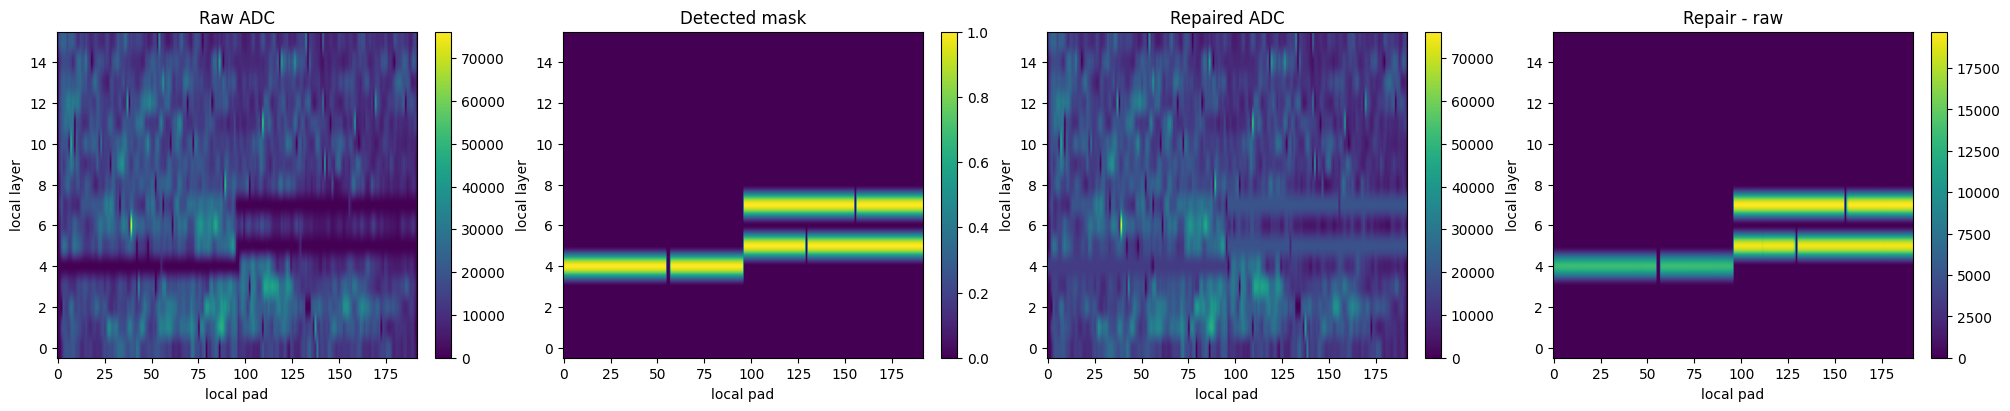

Dead FEE: []
Stripes: [('half-left', 4, 0.9791666666666666), ('half-right', 5, 0.9895833333333334), ('half-right', 7, 0.9895833333333334)]


In [7]:
QA_SIDE=0
QA_MODULE=2
QA_SECTOR=0

key=(QA_SIDE,QA_MODULE,QA_SECTOR)
if key in raw_maps:
    raw=raw_maps[key]["adc"]
    rep=clean_maps[key]
    m=auto_masks[key]
    mask=m["fee"] | m["stripe_half"] | m["stripe_full"]

    fig,ax=plt.subplots(1,4,figsize=(20,4),constrained_layout=True)
    for a,z,title in zip(
        ax,[raw,mask,rep,rep-raw],
        ["Raw ADC","Detected mask","Repaired ADC","Repair - raw"]
    ):
        im=a.imshow(z,aspect="auto",origin="lower")
        a.set_title(title)
        a.set_xlabel("local pad")
        a.set_ylabel("local layer")
        plt.colorbar(im,ax=a)
    plt.show()

    print("Dead FEE:",m["fee_regions"])
    print("Stripes:",m["stripe_details"])


## 5. Build measured global `(r,phi)` ADC and IBF-density maps

For each pad,

\[
A_{\rm pad}(r)\simeq r\,\Delta\phi\,\Delta r,
\qquad
\rho_{\rm IBF}\propto ADC/A_{\rm pad}.
\]

Bins with no physical pad coverage remain `NaN`, preserving sector gaps.


In [8]:
phi_edges=np.linspace(PHI_MIN,PHI_MAX,GLOBAL_PHI_BINS+1)
phi_centers=0.5*(phi_edges[:-1]+phi_edges[1:])
all_r=np.concatenate([module_layer_radii_cm(m) for m in range(N_MODULES)])
all_r=np.sort(all_r)

def phi_bin_index(phi):
    idx=np.floor((phi-PHI_MIN)/(PHI_MAX-PHI_MIN)*GLOBAL_PHI_BINS).astype(int)
    return np.clip(idx,0,GLOBAL_PHI_BINS-1)

def build_global_measured_maps(side):
    adc_sum=np.zeros((len(all_r),GLOBAL_PHI_BINS))
    rho_sum=np.zeros_like(adc_sum)
    counts=np.zeros_like(adc_sum)

    rlookup={}
    for module in range(N_MODULES):
        for il,r in enumerate(module_layer_radii_cm(module)):
            rlookup[(module,il)]=int(np.argmin(np.abs(all_r-r)))

    for module in range(N_MODULES):
        radii=module_layer_radii_cm(module)
        areas=pad_area_cm2(module,radii)

        for sector in range(N_SECTORS):
            key=(side,module,sector)
            if key not in clean_maps:
                continue
            a=clean_maps[key]
            phis=sector_phi_centers(module,sector,side)
            bins=phi_bin_index(phis)

            for il in range(LAYERS_PER_MODULE):
                ir=rlookup[(module,il)]
                for ip in range(a.shape[1]):
                    val=a[il,ip]
                    if not np.isfinite(val):
                        continue
                    ib=bins[ip]
                    adc_sum[ir,ib]+=val
                    rho_sum[ir,ib]+=val/areas[il]
                    counts[ir,ib]+=1

    adc=np.full_like(adc_sum,np.nan)
    rho=np.full_like(rho_sum,np.nan)
    good=counts>0
    adc[good]=adc_sum[good]/counts[good]
    rho[good]=rho_sum[good]/counts[good]
    return adc,rho,counts

adc_measured={}
ibf_measured={}
coverage_measured={}

for side in range(N_SIDES):
    adc_measured[side],ibf_measured[side],coverage_measured[side]=build_global_measured_maps(side)

print("Measured r-phi maps built")


Measured r-phi maps built


## 6. Extrapolate R1 smoothly inward to 21 cm

In [9]:
def extrapolate_to_ifc(measured,measured_r):
    first_r=measured_r[0]
    extra_r=np.linspace(IFC_RADIUS_CM,first_r,N_INNER_EXTRAP_BINS,endpoint=False)
    out_r=np.concatenate([extra_r,measured_r])
    out=np.full((len(out_r),measured.shape[1]),np.nan)
    out[len(extra_r):]=measured

    nfit=min(N_R1_FIT_LAYERS,measured.shape[0])
    rfit=measured_r[:nfit]

    for iphi in range(measured.shape[1]):
        y=measured[:nfit,iphi]
        good=np.isfinite(y)
        if not np.any(good):
            continue
        rg=rfit[good]
        yg=y[good]

        if IBF_R_EXTRAPOLATION=="constant" or len(yg)==1:
            pred=np.full_like(extra_r,yg[0])
        elif IBF_R_EXTRAPOLATION=="linear":
            coef=np.polyfit(rg,yg,min(1,len(yg)-1))
            pred=np.polyval(coef,extra_r)
        elif IBF_R_EXTRAPOLATION=="poly2":
            coef=np.polyfit(rg,yg,min(2,len(yg)-1))
            pred=np.polyval(coef,extra_r)
        else:
            raise ValueError(IBF_R_EXTRAPOLATION)

        out[:len(extra_r),iphi]=np.clip(pred,0,None)

    return out_r,out,len(extra_r)

ibf_map={}
adc_map={}

for side in range(N_SIDES):
    r_full,ibf_map[side],n_extrap=extrapolate_to_ifc(ibf_measured[side],all_r)
    _,adc_map[side],_=extrapolate_to_ifc(adc_measured[side],all_r)

print(f"Added {n_extrap} inner radial rows")


Added 20 inner radial rows


## 7. Final IBF maps and r / phi profiles

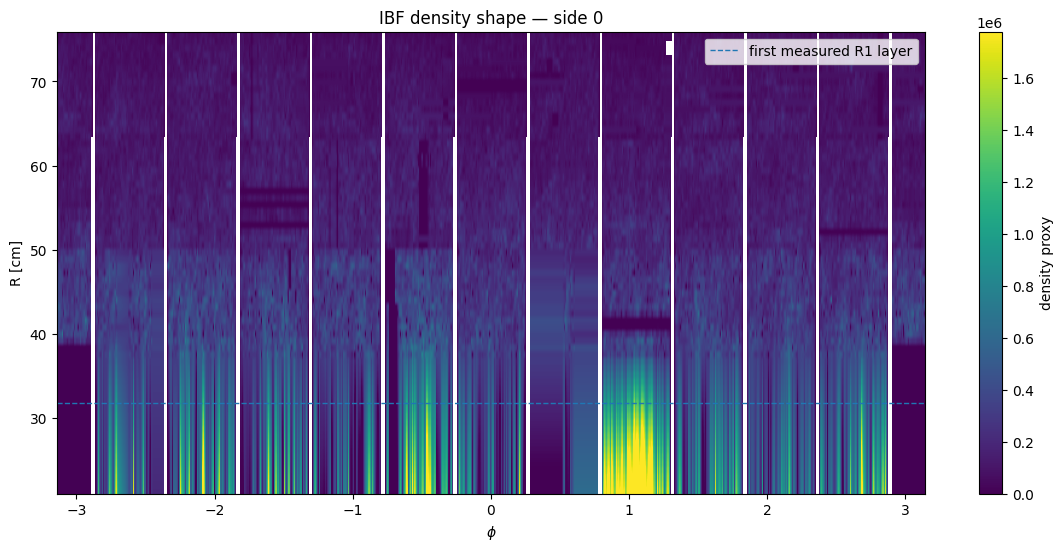

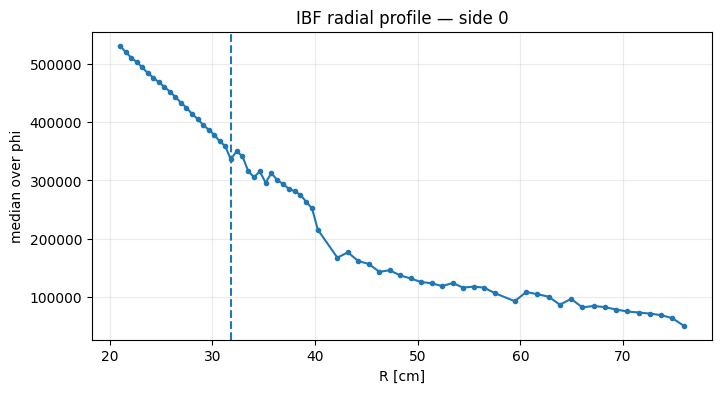

/tmp/ipykernel_13164/2582115956.py:29: RuntimeWarning: All-NaN slice encountered
  plt.plot(phi_centers,np.nanmedian(ibf_map[side],axis=0))


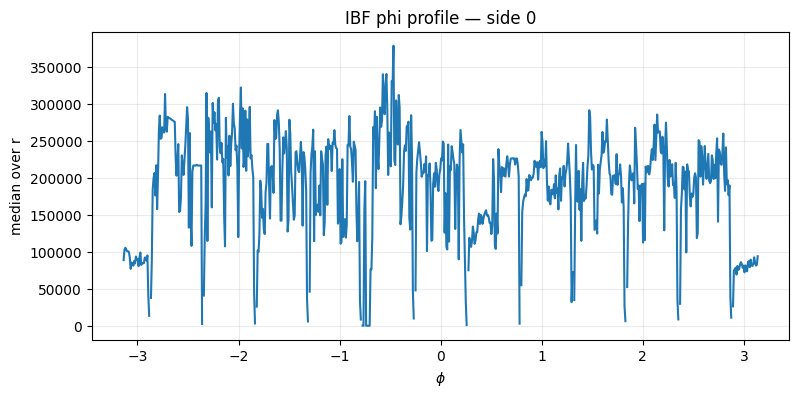

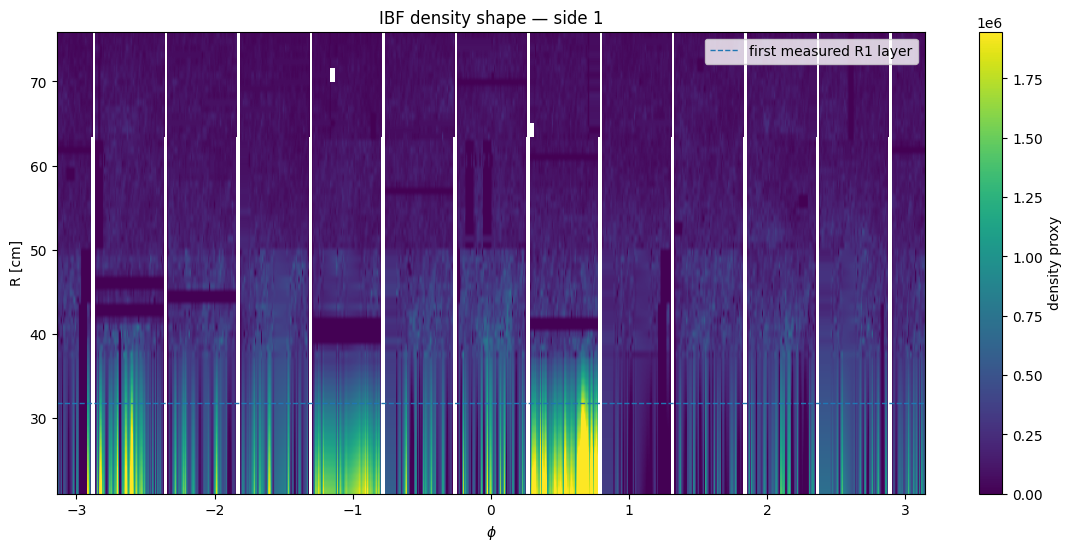

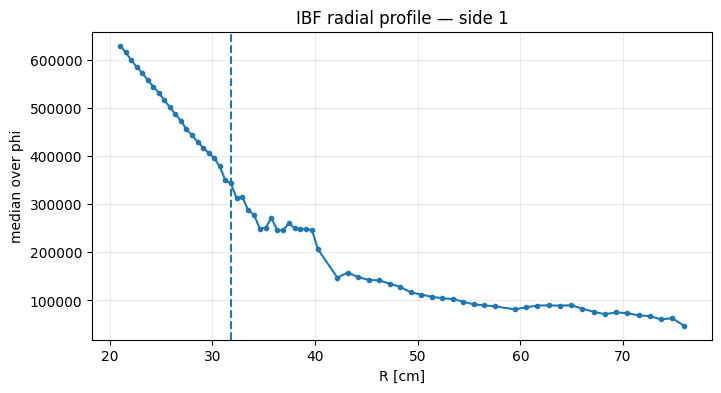

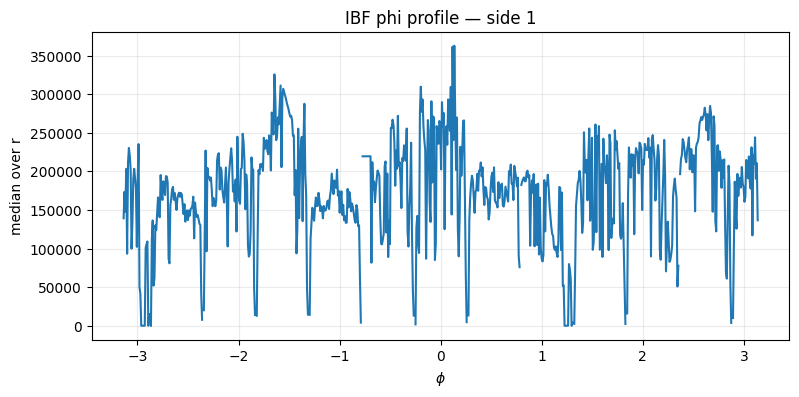

In [10]:
def plot_rphi(data,rvals,title,label="density proxy"):
    finite=data[np.isfinite(data)]
    vmax=np.quantile(finite,0.995) if finite.size else None
    plt.figure(figsize=(14,6))
    plt.imshow(data,origin="lower",aspect="auto",
               extent=[PHI_MIN,PHI_MAX,rvals[0],rvals[-1]],
               vmin=0,vmax=vmax)
    plt.xlabel(r"$\phi$")
    plt.ylabel("R [cm]")
    plt.title(title)
    plt.colorbar(label=label)
    plt.axhline(all_r[0],ls="--",lw=1,label="first measured R1 layer")
    plt.legend()
    plt.show()

for side in range(N_SIDES):
    plot_rphi(ibf_map[side],r_full,f"IBF density shape — side {side}")

    plt.figure(figsize=(8,4))
    plt.plot(r_full,np.nanmedian(ibf_map[side],axis=1),marker=".")
    plt.axvline(all_r[0],ls="--")
    plt.xlabel("R [cm]")
    plt.ylabel("median over phi")
    plt.title(f"IBF radial profile — side {side}")
    plt.grid(alpha=0.25)
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(phi_centers,np.nanmedian(ibf_map[side],axis=0))
    plt.xlabel(r"$\phi$")
    plt.ylabel("median over r")
    plt.title(f"IBF phi profile — side {side}")
    plt.grid(alpha=0.25)
    plt.show()


## 8. Smooth 2D diagnostic fit in both r and phi

Periodic Fourier terms in phi are combined with low-order radial polynomials:

\[
\rho(r,\phi)=
\sum_k a_k r_n^k+
\sum_{n=1}^{N}\sum_k
\left[b_{nk}r_n^k\cos(n\phi)+c_{nk}r_n^k\sin(n\phi)\right].
\]

This is only a diagnostic representation. The repaired histogram can remain the
actual PHGarfield source.


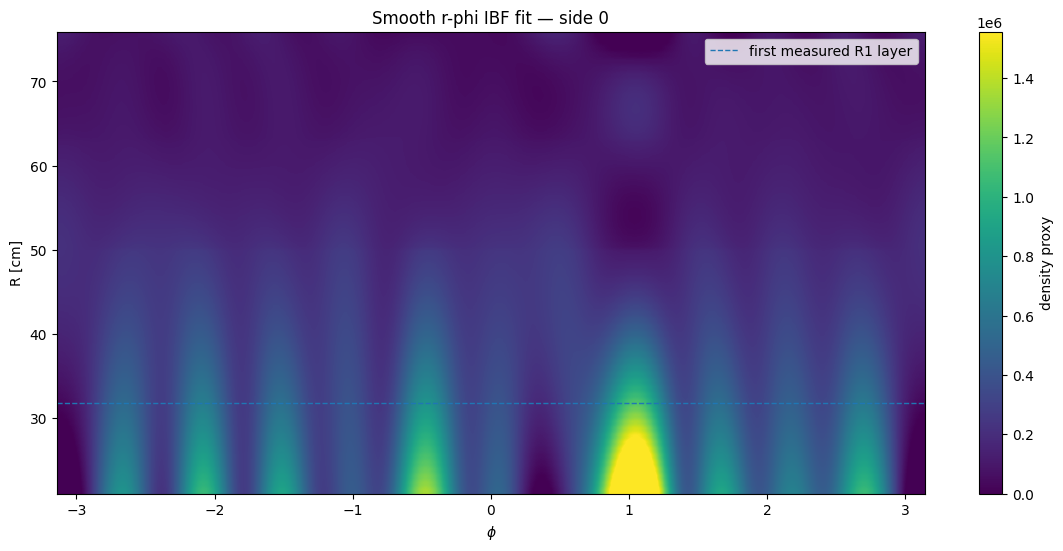

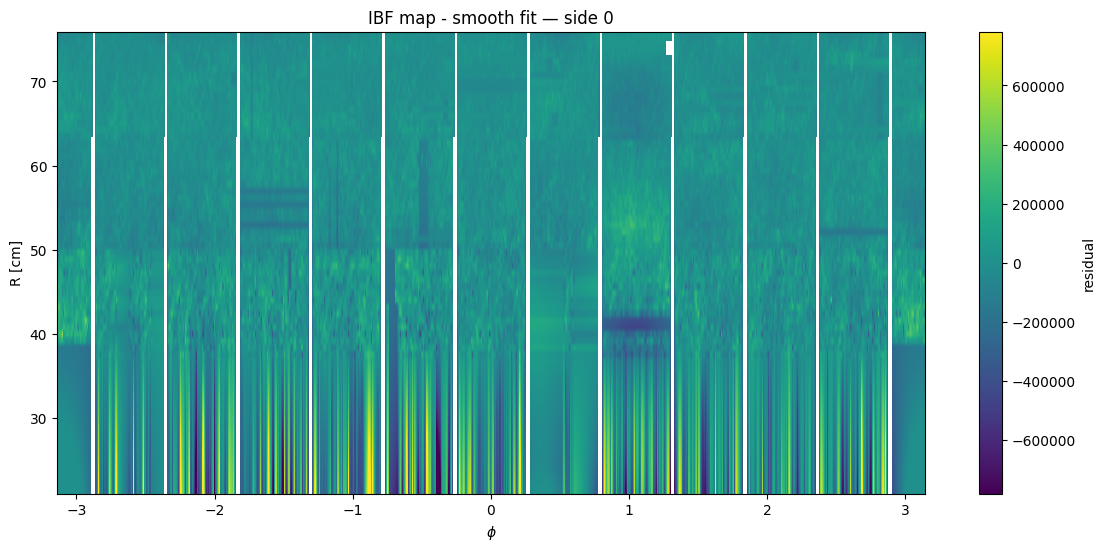

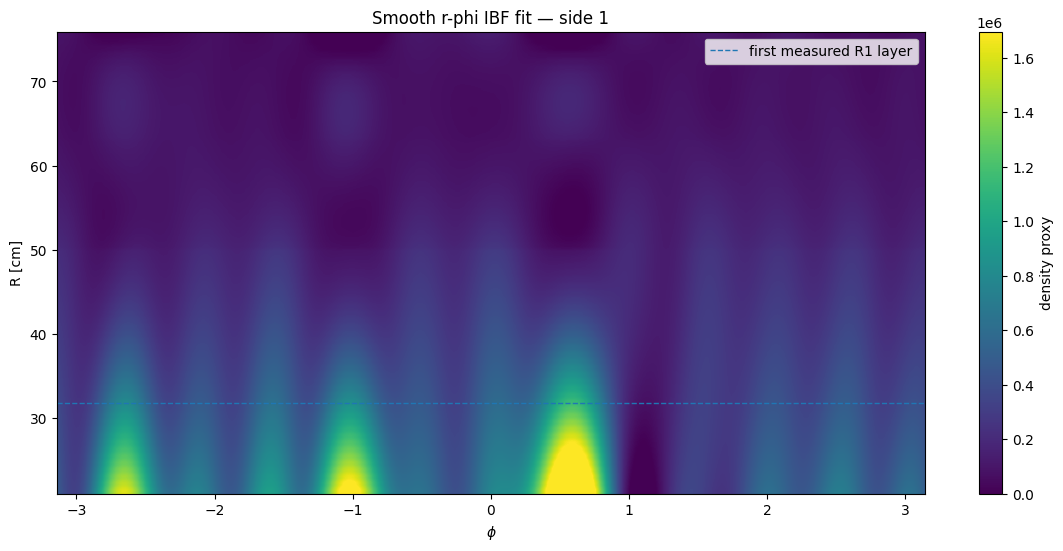

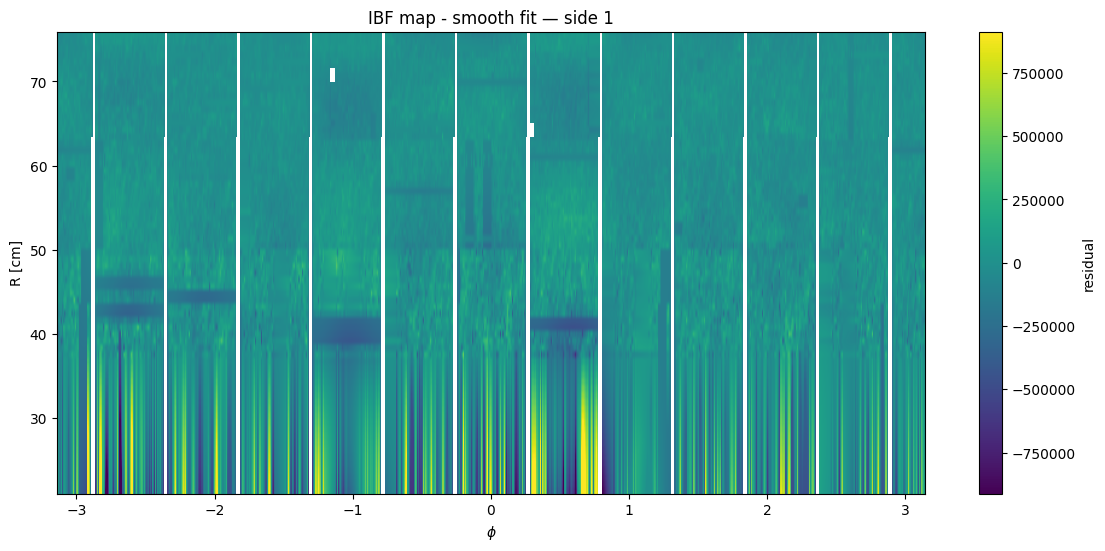

In [11]:
def design_matrix(r,phi):
    r=np.asarray(r,float)
    phi=np.asarray(phi,float)
    rmid=0.5*(r_full.min()+r_full.max())
    rscale=0.5*(r_full.max()-r_full.min())
    rn=(r-rmid)/rscale

    cols=[]
    names=[]

    for k in range(RADIAL_POLY_ORDER+1):
        cols.append(rn**k)
        names.append(f"r^{k}")

    for n in range(1,FOURIER_ORDER+1):
        for k in range(RADIAL_POLY_ORDER+1):
            cols.append((rn**k)*np.cos(n*phi))
            names.append(f"r^{k} cos({n}phi)")
        for k in range(RADIAL_POLY_ORDER+1):
            cols.append((rn**k)*np.sin(n*phi))
            names.append(f"r^{k} sin({n}phi)")

    return np.column_stack(cols),names

def fit_smooth_rphi(data,rvals,phivals):
    R,P=np.meshgrid(rvals,phivals,indexing="ij")
    y=data.ravel()
    rr=R.ravel()
    pp=P.ravel()
    good=np.isfinite(y) & (y>=FIT_MIN_DENSITY)

    X,names=design_matrix(rr[good],pp[good])
    coef,*_=np.linalg.lstsq(X,y[good],rcond=None)

    Xall,_=design_matrix(rr,pp)
    pred=(Xall@coef).reshape(data.shape)
    return coef,names,np.clip(pred,0,None)

ibf_fit={}
ibf_fit_coeff={}

for side in range(N_SIDES):
    coef,names,pred=fit_smooth_rphi(ibf_map[side],r_full,phi_centers)
    ibf_fit[side]=pred
    ibf_fit_coeff[side]=(coef,names)

    plot_rphi(pred,r_full,f"Smooth r-phi IBF fit — side {side}")

    resid=ibf_map[side]-pred
    finite=resid[np.isfinite(resid)]
    lim=np.quantile(np.abs(finite),0.995) if finite.size else None
    plt.figure(figsize=(14,6))
    plt.imshow(resid,origin="lower",aspect="auto",
               extent=[PHI_MIN,PHI_MAX,r_full[0],r_full[-1]],
               vmin=-lim if lim else None,vmax=lim)
    plt.xlabel(r"$\phi$")
    plt.ylabel("R [cm]")
    plt.title(f"IBF map - smooth fit — side {side}")
    plt.colorbar(label="residual")
    plt.show()


# Part II — primary-ionization density

This part starts from `adc_map`, not from `ibf_map`.

With a gain map:

\[
\rho_{\rm primary}\propto\frac{ADC_{\rm cleaned}}
{G(r,\phi)\,A_{\rm pad}(r)}.
\]

For now, if no gain map is supplied, gain is set to one everywhere.


In [12]:
def sample_gain_map(side):
    gain=np.ones((len(r_full),GLOBAL_PHI_BINS))

    if GAIN_MAP_FILE is None or GAIN_MAP_HIST is None:
        return gain

    fg=root.TFile.Open(GAIN_MAP_FILE,"READ")
    if not fg or fg.IsZombie():
        raise OSError(GAIN_MAP_FILE)

    hname=GAIN_MAP_HIST.format(side=side)
    hg=fg.Get(hname)
    if not hg:
        raise KeyError(hname)

    for ir,r in enumerate(r_full):
        for ip,phi in enumerate(phi_centers):
            g=hg.GetBinContent(hg.FindBin(phi,r))
            gain[ir,ip]=g if np.isfinite(g) and g>0 else np.nan

    fg.Close()
    return gain

def area_grid_for_rphi(rvals):
    out=np.empty(len(rvals))
    # For inner extrapolation use R1 pad geometry.
    r01=0.5*(np.mean(module_layer_radii_cm(0))+np.mean(module_layer_radii_cm(1)))
    r12=0.5*(np.mean(module_layer_radii_cm(1))+np.mean(module_layer_radii_cm(2)))

    for i,r in enumerate(rvals):
        if r<r01:
            m=0
        elif r<r12:
            m=1
        else:
            m=2
        out[i]=r*AVR_DPHI_MODULE[m]*module_dr_cm(m)
    return out[:,None]

gain_map={}
primary_map={}
area_grid=area_grid_for_rphi(r_full)

for side in range(N_SIDES):
    gain_map[side]=sample_gain_map(side)
    base=adc_map[side]/area_grid
    primary_map[side]=base/gain_map[side] if PRIMARY_DIVIDE_BY_GAIN else base

print("Primary maps built")


Primary maps built


## Primary maps, profiles, and 2D fits

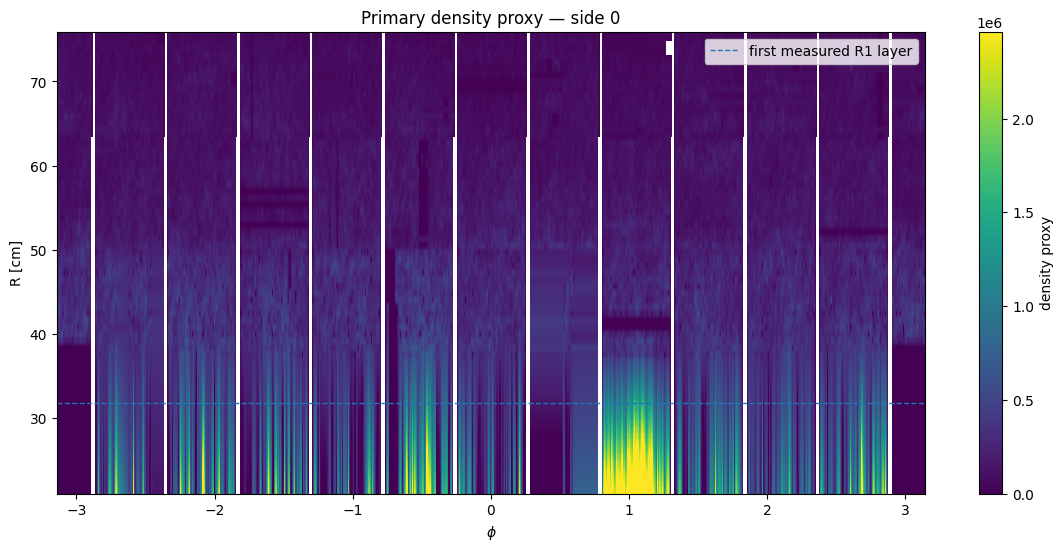

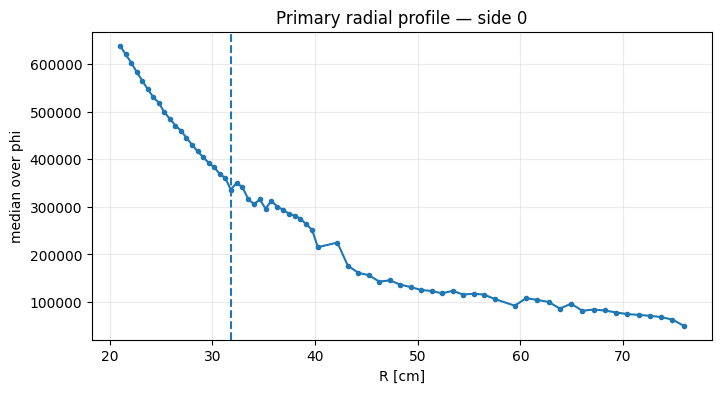

/tmp/ipykernel_13164/199592878.py:17: RuntimeWarning: All-NaN slice encountered
  plt.plot(phi_centers,np.nanmedian(primary_map[side],axis=0))


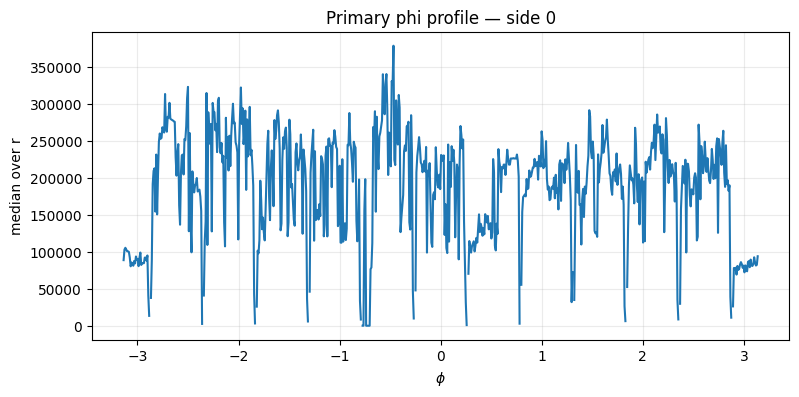

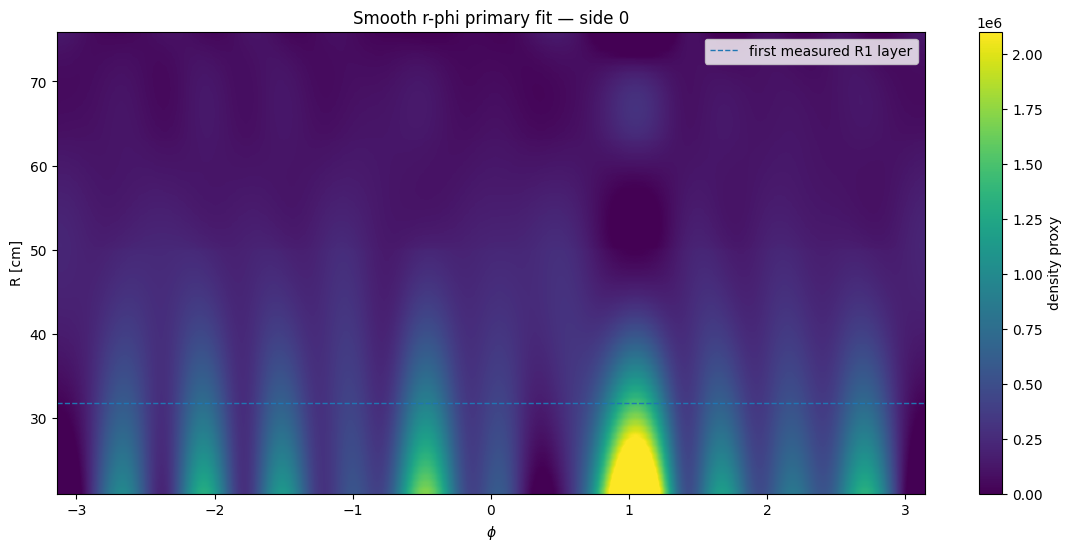

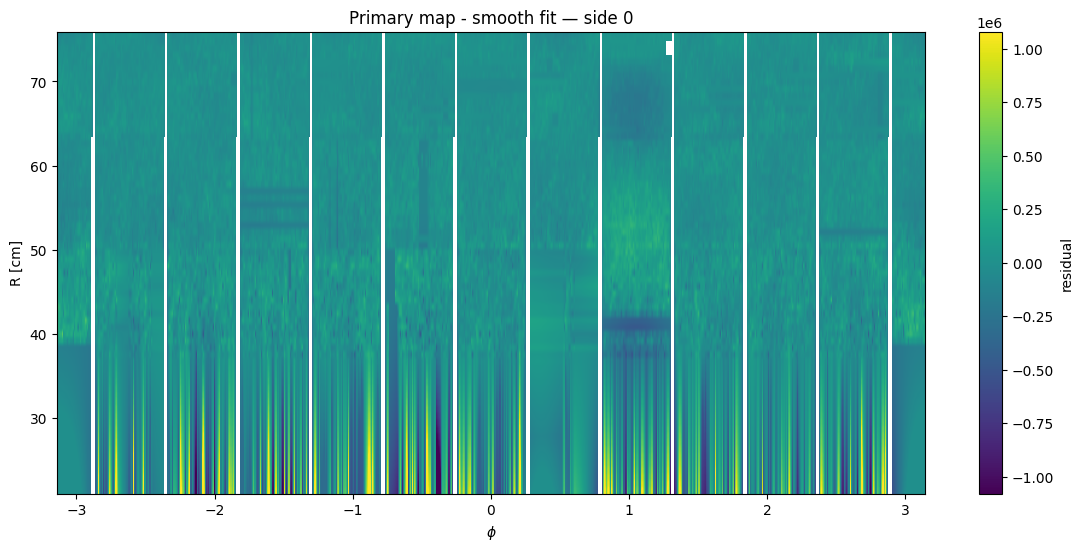

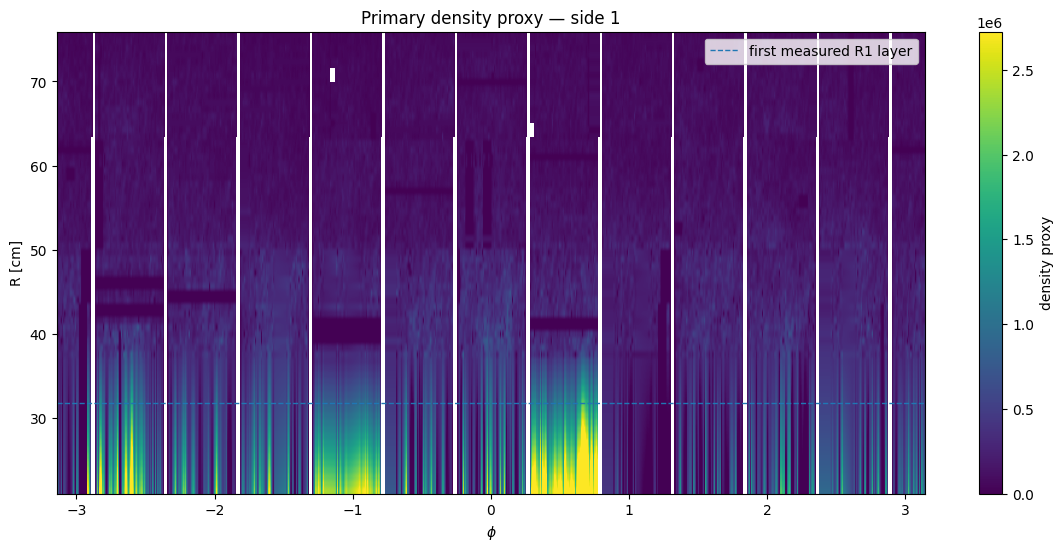

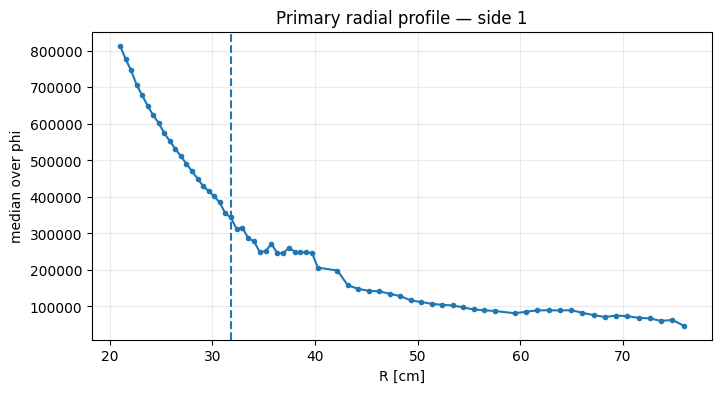

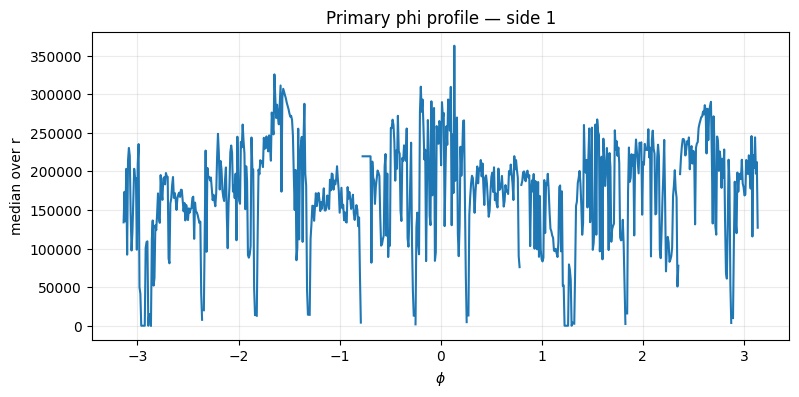

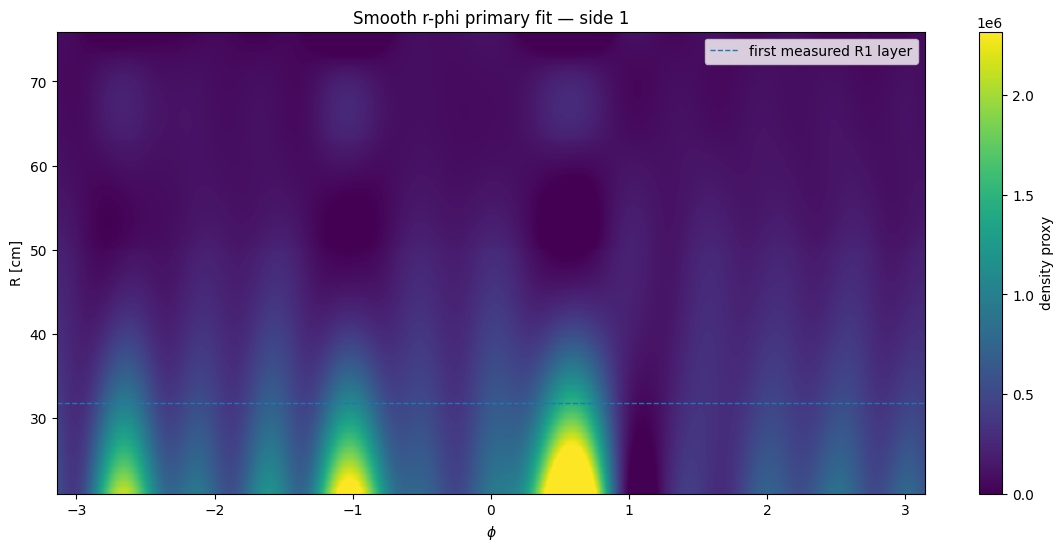

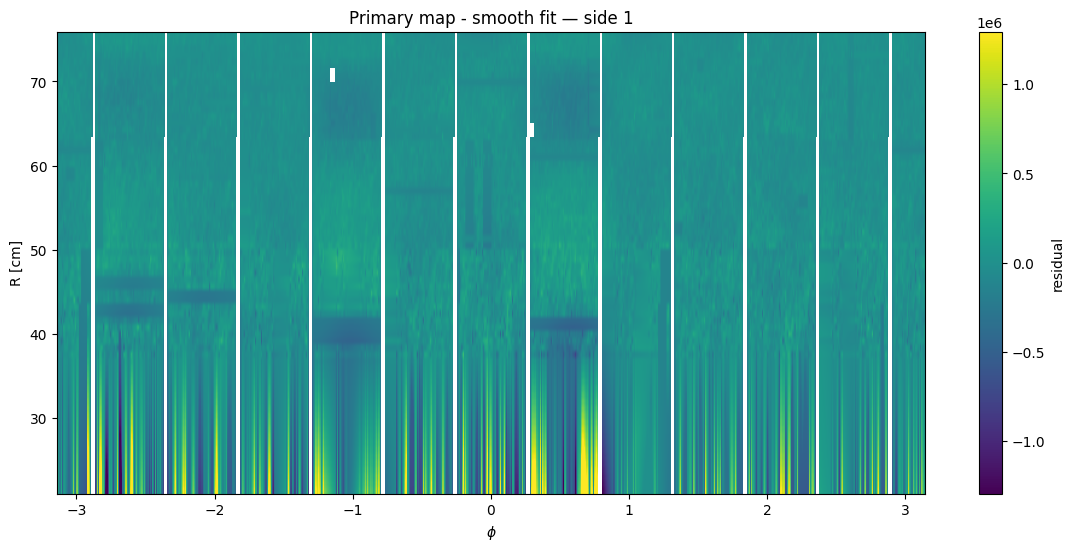

In [13]:
primary_fit={}
primary_fit_coeff={}

for side in range(N_SIDES):
    plot_rphi(primary_map[side],r_full,f"Primary density proxy — side {side}")

    plt.figure(figsize=(8,4))
    plt.plot(r_full,np.nanmedian(primary_map[side],axis=1),marker=".")
    plt.axvline(all_r[0],ls="--")
    plt.xlabel("R [cm]")
    plt.ylabel("median over phi")
    plt.title(f"Primary radial profile — side {side}")
    plt.grid(alpha=0.25)
    plt.show()

    plt.figure(figsize=(9,4))
    plt.plot(phi_centers,np.nanmedian(primary_map[side],axis=0))
    plt.xlabel(r"$\phi$")
    plt.ylabel("median over r")
    plt.title(f"Primary phi profile — side {side}")
    plt.grid(alpha=0.25)
    plt.show()

    coef,names,pred=fit_smooth_rphi(primary_map[side],r_full,phi_centers)
    primary_fit[side]=pred
    primary_fit_coeff[side]=(coef,names)
    plot_rphi(pred,r_full,f"Smooth r-phi primary fit — side {side}")

    resid=primary_map[side]-pred
    finite=resid[np.isfinite(resid)]
    lim=np.quantile(np.abs(finite),0.995) if finite.size else None
    plt.figure(figsize=(14,6))
    plt.imshow(resid,origin="lower",aspect="auto",
               extent=[PHI_MIN,PHI_MAX,r_full[0],r_full[-1]],
               vmin=-lim if lim else None,vmax=lim)
    plt.xlabel(r"$\phi$")
    plt.ylabel("R [cm]")
    plt.title(f"Primary map - smooth fit — side {side}")
    plt.colorbar(label="residual")
    plt.show()


## Save the final maps to ROOT

In [14]:
def centers_to_edges(x):
    x=np.asarray(x,float)
    e=np.empty(len(x)+1)
    e[1:-1]=0.5*(x[:-1]+x[1:])
    e[0]=x[0]-0.5*(x[1]-x[0])
    e[-1]=x[-1]+0.5*(x[-1]-x[-2])
    return e

def numpy_to_th2(name,title,data,rvals):
    pedges=np.linspace(PHI_MIN,PHI_MAX,GLOBAL_PHI_BINS+1)
    redges=centers_to_edges(rvals)
    h=root.TH2D(name,title,
                GLOBAL_PHI_BINS,array("d",pedges),
                len(rvals),array("d",redges))
    h.SetDirectory(0)

    for ir in range(len(rvals)):
        for ip in range(GLOBAL_PHI_BINS):
            v=data[ir,ip]
            h.SetBinContent(ip+1,ir+1,float(v) if np.isfinite(v) else 0.0)
    return h

fout=root.TFile.Open(OUTPUT_ROOT,"RECREATE")

for side in range(N_SIDES):
    hs=[
        numpy_to_th2(
            f"h_adc_clean_rphi_side{side}",
            f"Cleaned ADC side {side};#phi;R [cm];ADC/event",
            adc_map[side],r_full),
        numpy_to_th2(
            f"h_ibf_density_shape_rphi_side{side}",
            f"IBF density shape side {side};#phi;R [cm];arb. density",
            ibf_map[side],r_full),
        numpy_to_th2(
            f"h_ibf_density_fit_rphi_side{side}",
            f"Smooth IBF fit side {side};#phi;R [cm];arb. density",
            ibf_fit[side],r_full),
        numpy_to_th2(
            f"h_primary_density_rphi_side{side}",
            f"Primary density side {side};#phi;R [cm];arb. density",
            primary_map[side],r_full),
        numpy_to_th2(
            f"h_primary_density_fit_rphi_side{side}",
            f"Smooth primary fit side {side};#phi;R [cm];arb. density",
            primary_fit[side],r_full),
    ]
    for h in hs:
        h.Write()

fout.Close()
print("Wrote",OUTPUT_ROOT)


Wrote TPC_IBF_primary_maps.root


## First validation pass

Before the map is used in PHGarfield, I would inspect:

1. several automatic FEE/stripe masks by hand;
2. whether any true sector/module boundary is falsely repaired;
3. `raw`, `sum`, `mean`, `median`, and `trimmed_mean`;
4. continuity of the 21 cm → first-R1 extrapolation;
5. side 0 and side 1 separately;
6. residuals of the smooth 2D fit, especially 12-fold phi structure;
7. only then fit the global IBF normalization with PHGarfield/data.
